In [1]:
import sys, os
import pandas as pd
from utils.misc import cols_to_front
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [2]:
merged_df = pd.read_csv('data/merged_ai_descriptors_clean.csv')

df = pd.read_csv('data/local_df_ai_descriptors.csv')
df1 = pd.read_csv('data/merged_ai_descriptors_dummies_filtered.csv')

merged_df.rename(columns={'ai_descriptors': 'raw_AI_output'}, inplace=True)
df1.head()

,Nom scientifique,acid,airy,anise,apple,aroma,astringent,bean,beef,berry,...,cat_animal product,cat_beverage,cat_fruit,cat_fungus,cat_grains,cat_nuts,cat_plant,cat_prepared food,cat_tuber,cat_vegetable
0,Macrocystis pyrifera,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,Palmaria palmata,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,Porphyra perforata,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,Porphyra abbottae,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,Porphyra torta,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Make quick cosine comparisons

In [3]:
local = merged_df[merged_df['db'] == 'local']
flavor_db = merged_df[merged_df['db'] == 'flavor_db']

local_names = local['Nom scientifique'].to_list()
flavor_db_names = flavor_db['Nom scientifique'].to_list()

In [4]:
num_cols = df1.drop(columns=['Nom scientifique']).columns
local_vec = np.array(df1.loc[df1['Nom scientifique'].isin(local_names)][num_cols])
flavor_db_vec = np.array(df1.loc[df1['Nom scientifique'].isin(flavor_db_names)][num_cols])

similarity_matrix = cosine_similarity(X= local_vec, Y = flavor_db_vec)
similarity_matrix

array([[0.36980013, 0.20254787, 0.23076923, ..., 0.18490007, 0.16012815,
        0.1754116 ],
       [0.36980013, 0.30382181, 0.23076923, ..., 0.18490007, 0.08006408,
        0.1754116 ],
       [0.36980013, 0.20254787, 0.23076923, ..., 0.18490007, 0.16012815,
        0.1754116 ],
       ...,
       [0.10540926, 0.11547005, 0.0877058 , ..., 0.10540926, 0.18257419,
        0.1       ],
       [0.18490007, 0.25318484, 0.15384615, ..., 0.2773501 , 0.24019223,
        0.1754116 ],
       [0.10540926, 0.11547005, 0.0877058 , ..., 0.10540926, 0.09128709,
        0.1       ]], shape=(168, 934))

In [5]:
# filter local ing that have a decent enough match
max_indices_per_row = np.argmax(similarity_matrix, axis=1)

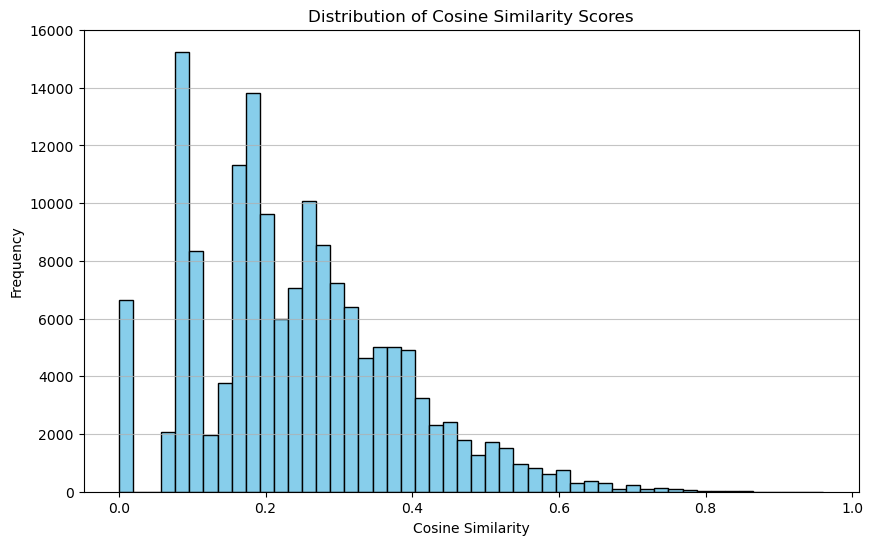

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(similarity_matrix.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
similarity_df = pd.DataFrame(similarity_matrix, index=local_names, columns=flavor_db_names)
similarity_df.to_excel('data/similarity_matrix.xlsx', index=True)
display(similarity_df.head())

,Egg,Bakery Products,Bread,Rye Bread,Wheaten Bread,White Bread,Wholewheat Bread,Wort,Arrack,Beer,...,Margarine like spread,Hummus,Potato puffs,Potato gratin,Chinese bayberry,Green zucchini,Yellow zucchini,Saskatoon berry,Nanking cherry,Japanese pumpkin
Macrocystis pyrifera,0.369800,0.202548,0.230769,0.153846,0.230769,0.080064,0.230769,0.230769,0.240192,0.221880,...,0.307692,0.384615,0.418121,0.358057,0.083624,0.350823,0.263117,0.184900,0.160128,0.175412
Palmaria palmata,0.369800,0.303822,0.230769,0.153846,0.230769,0.160128,0.153846,0.230769,0.240192,0.166410,...,0.307692,0.307692,0.418121,0.429669,0.083624,0.350823,0.350823,0.184900,0.080064,0.175412
Porphyra perforata,0.369800,0.202548,0.230769,0.153846,0.230769,0.080064,0.230769,0.230769,0.240192,0.221880,...,0.307692,0.384615,0.418121,0.358057,0.083624,0.350823,0.263117,0.184900,0.160128,0.175412
Porphyra abbottae,0.288675,0.158114,0.160128,0.160128,0.160128,0.083333,0.240192,0.240192,0.166667,0.173205,...,0.240192,0.320256,0.348155,0.298142,0.087039,0.365148,0.273861,0.192450,0.166667,0.182574
Porphyra torta,0.481125,0.263523,0.320256,0.240192,0.320256,0.250000,0.240192,0.320256,0.250000,0.173205,...,0.320256,0.400320,0.435194,0.447214,0.087039,0.273861,0.456435,0.288675,0.083333,0.273861


In [8]:
# Save similarity matrix for all ingredient
ing_names = df1["Nom scientifique"].to_list()

X = df1[num_cols].values

similarity_matrix = cosine_similarity(X)
similarity_df = pd.DataFrame(similarity_matrix, index=ing_names, columns=ing_names)
similarity_df.to_csv('data/similarity_matrix_all_ing.csv', index=True)

## Get best matches stats

In [9]:
stats = similarity_df.T.describe().T
stats = stats.sort_values(by='max', ascending=False)

stats.to_excel('output/similarity_matrix_stats_local.xlsx', index=True)

In [10]:
stats = similarity_df.describe().T
stats = stats.sort_values(by='max', ascending=False)

stats.to_excel('output/similarity_matrix_stats_flavordb.xlsx', index=True)

In [11]:
local_ing = local['Nom scientifique'].to_list()
similarity_df

,Macrocystis pyrifera,Palmaria palmata,Porphyra perforata,Porphyra abbottae,Porphyra torta,Porphyra pseudolancelata,Alaria esculenta,Alaria marginata,Alaria pylaii,Laminaria groenlandica,...,Margarine like spread,Hummus,Potato puffs,Potato gratin,Chinese bayberry,Green zucchini,Yellow zucchini,Saskatoon berry,Nanking cherry,Japanese pumpkin
Macrocystis pyrifera,1.000000,0.846154,0.923077,0.880705,0.800641,0.800641,0.923077,0.923077,0.889499,0.923077,...,0.307692,0.384615,0.418121,0.358057,0.083624,0.350823,0.263117,0.184900,0.160128,0.175412
Palmaria palmata,0.846154,1.000000,0.846154,0.720577,0.800641,0.880705,0.769231,0.769231,0.741249,0.846154,...,0.307692,0.307692,0.418121,0.429669,0.083624,0.350823,0.350823,0.184900,0.080064,0.175412
Porphyra perforata,0.923077,0.846154,1.000000,0.880705,0.800641,0.800641,0.846154,0.846154,0.815374,0.846154,...,0.307692,0.384615,0.418121,0.358057,0.083624,0.350823,0.263117,0.184900,0.160128,0.175412
Porphyra abbottae,0.880705,0.720577,0.880705,1.000000,0.750000,0.750000,0.880705,0.880705,0.848668,0.880705,...,0.240192,0.320256,0.348155,0.298142,0.087039,0.365148,0.273861,0.192450,0.166667,0.182574
Porphyra torta,0.800641,0.800641,0.800641,0.750000,1.000000,0.916667,0.800641,0.800641,0.771517,0.800641,...,0.320256,0.400320,0.435194,0.447214,0.087039,0.273861,0.456435,0.288675,0.083333,0.273861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Green zucchini,0.350823,0.350823,0.350823,0.365148,0.273861,0.365148,0.438529,0.438529,0.422577,0.350823,...,0.087706,0.175412,0.286039,0.244949,0.190693,1.000000,0.700000,0.316228,0.273861,0.200000
Yellow zucchini,0.263117,0.350823,0.263117,0.273861,0.456435,0.456435,0.350823,0.350823,0.338062,0.263117,...,0.087706,0.175412,0.286039,0.326599,0.286039,0.700000,1.000000,0.421637,0.273861,0.300000
Saskatoon berry,0.184900,0.184900,0.184900,0.192450,0.288675,0.288675,0.184900,0.184900,0.178174,0.184900,...,0.092450,0.184900,0.201008,0.258199,0.502519,0.316228,0.421637,1.000000,0.481125,0.527046
Nanking cherry,0.160128,0.080064,0.160128,0.166667,0.083333,0.083333,0.240192,0.240192,0.231455,0.160128,...,0.080064,0.160128,0.087039,0.074536,0.609272,0.273861,0.273861,0.481125,1.000000,0.273861


In [12]:
# 1) drop columns whose names are in local_names
sim = similarity_df.drop(columns=local_names, errors="ignore")

# (optional but usually desired) don't let an item pick itself as a top neighbor
# this only affects rows whose name is also a remaining column
# common = sim.index.intersection(sim.columns)
# sim.loc[common, common] = -np.inf

# 2) top-3 per row (vectorized)
A = sim.to_numpy()
k = 3

# indices of top-k (unordered), then sort those k by score desc
topk_idx = np.argpartition(A, -k, axis=1)[:, -k:]
topk_scores = np.take_along_axis(A, topk_idx, axis=1)
order = np.argsort(-topk_scores, axis=1)

topk_idx = np.take_along_axis(topk_idx, order, axis=1)
topk_scores = np.take_along_axis(topk_scores, order, axis=1)

topk_names = sim.columns.to_numpy()[topk_idx]

# 3) pack into a result df
out = pd.DataFrame(
    {
        "top1_name": topk_names[:, 0], "top1_score": topk_scores[:, 0],
        "top2_name": topk_names[:, 1], "top2_score": topk_scores[:, 1],
        "top3_name": topk_names[:, 2], "top3_score": topk_scores[:, 2],
    },
    index=sim.index
)

out_local = out.loc[out.index.intersection(local_names)]
out_local 


,top1_name,top1_score,top2_name,top2_score,top3_name,top3_score
Macrocystis pyrifera,Kombu,0.836242,Purple laver,0.836242,Red algae,0.836242
Palmaria palmata,Leather chiton,0.752618,Red algae,0.752618,Kombu,0.752618
Porphyra perforata,Purple laver,0.752618,Leather chiton,0.752618,Clam,0.752618
Porphyra abbottae,Irish moss,0.866025,Red algae,0.783349,Purple laver,0.783349
Porphyra torta,Red algae,0.783349,Kombu,0.783349,Krill,0.769800
...,...,...,...,...,...,...
Arcticum lappa,Thistle,0.739600,Yellow pond lily,0.739600,Chicory,0.701646
Arcticum minus,Endive,0.783349,Mountain yam,0.696311,Kohlrabi,0.673575
Artemisia campestris,Artemisia,0.790569,Clove,0.701646,Oregano,0.613941
Artemisia dracunculus,Dill,0.769231,Cinnamon,0.720577,Giant butterbur,0.720577


In [13]:
# 1) drop columns whose names are in flavor_db_names
sim = similarity_df.drop(columns=flavor_db_names, errors="ignore")

# (optional but usually desired) don't let an item pick itself as a top neighbor
# this only affects rows whose name is also a remaining column
# common = sim.index.intersection(sim.columns)
# sim.loc[common, common] = -np.inf

# 2) top-3 per row (vectorized)
A = sim.to_numpy()
k = 3

# indices of top-k (unordered), then sort those k by score desc
topk_idx = np.argpartition(A, -k, axis=1)[:, -k:]
topk_scores = np.take_along_axis(A, topk_idx, axis=1)
order = np.argsort(-topk_scores, axis=1)

topk_idx = np.take_along_axis(topk_idx, order, axis=1)
topk_scores = np.take_along_axis(topk_scores, order, axis=1)

topk_names = sim.columns.to_numpy()[topk_idx]

# 3) pack into a result df
out = pd.DataFrame(
    {
        "top1_name": topk_names[:, 0], "top1_score": topk_scores[:, 0],
        "top2_name": topk_names[:, 1], "top2_score": topk_scores[:, 1],
        "top3_name": topk_names[:, 2], "top3_score": topk_scores[:, 2],
    },
    index=sim.index
)

out_flavor_db = out.loc[out.index.intersection(flavor_db_names)]
out_flavor_db 

,top1_name,top1_score,top2_name,top2_score,top3_name,top3_score
Egg,Pinus albicaulis,0.577350,Agaricus campestris,0.527046,Pleurotus ostreatus,0.527046
Bakery Products,Calvatia gigantea,0.385337,Cantarellus ?cibarius,0.368932,Sium suave,0.354459
Bread,Acer macrophyllum,0.480384,Pinus albicaulis,0.480384,Acer negundo,0.438529
Rye Bread,Arisaema atrorubens,0.462250,Zizania aquatica,0.429669,A. racemosa,0.400320
Wheaten Bread,Acer macrophyllum,0.480384,Cantarellus ?cibarius,0.480384,Pinus albicaulis,0.480384
...,...,...,...,...,...,...
Green zucchini,Carex aquatilis,0.800000,Scirpus lacustris,0.800000,Amaranthus retroflexus,0.730297
Yellow zucchini,Smilacina trifolia,0.700000,Erythronium americanum,0.700000,Carex aquatilis,0.700000
Saskatoon berry,Smilacina trifolia,0.632456,Smilacina stellata,0.527046,Asparagus officinalis,0.481125
Nanking cherry,Rhus glabra,0.666667,R. typhina,0.522233,Smilacina trifolia,0.456435


## Find best matching to local ingredients 


In [14]:
# Merge top matches with local df
output = local.merge(
    out_local,
    left_on="Nom scientifique",
    right_index=True,
    how="left"
)

# Add nom vernaculaire 
output = output.merge(
    df[["Nom scientifique", "Nom vernaculaire"]],
    on="Nom scientifique",
    how="left"
)

# Compact all the matches in a single column
name_cols = [col for col in output.columns if col.endswith("_name")]
output["matches"] = output[name_cols].apply(
    lambda row: ", ".join(row.dropna().astype(str)),
    axis=1
)


output = output.dropna(subset=['Nom scientifique'])
output = cols_to_front(output, ["Nom scientifique", "Nom vernaculaire", "matches"])

In [15]:
# Save
output.to_excel("output/local_ingredients_top3_matches.xlsx", index=False)

In [16]:
output = flavor_db.merge(
    out_flavor_db ,
    left_on="Nom scientifique",
    right_index=True,
    how="left"
)
output

# Compact all the matches in a single column
name_cols = [col for col in output.columns if col.endswith("_name")]
output["matches"] = output[name_cols].apply(
    lambda row: ", ".join(row.dropna().astype(str)),
    axis=1
)

output = output.dropna(subset=['Nom scientifique'])
output = cols_to_front(output, ["Nom scientifique", "matches"])
output = output.dropna(subset=['Nom scientifique'])


In [17]:
# Save
output.to_excel("output/flavordb_ingredients_top3_matches.xlsx", index=False)

# Searching

In [18]:
kw = "iso"
flavor_db.loc[flavor_db['Nom scientifique'].str.contains(kw)]

,Nom scientifique,raw_AI_output,sub_category,db,category,descriptor
673,Bison,"gamey,earthy,lean,rich,slightly sweet,beefy,cl...",meat,flavor_db,animal product,"game,earth,lean,sweet,beef,clean,robust,grass,..."
964,Miso,"salty,umami,savory,earthy,rich,fermented,sligh...",additive,flavor_db,plant,"salt,umami,savory,earth,fermented,sweet,tang,m..."


In [19]:
flavor_db.shape

(934, 6)